In [1]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import shuffle


In [2]:
train_labels=[]
train_samples=[]


An experiemental drug was tested on individuals from ages 13 to 100 in a clinical trial.

The trial had 2100 participants. Half were under 65 years old, half were 65 years or older.

Around 95% of patients 65 or older experienced side effects.

Around 95% of patients under 65 experienced no side effects.

In [3]:
from random import randint


for age in  range(50):
    # 5% od the sample is younger who did  experinced the side effects
    random_younger=randint(13,64)
    train_samples.append(random_younger)
    train_labels.append(1)
   #5% of the sample is older who did not experinced the side effects(outliers)
    random_older=randint(65,100)
    train_samples.append(random_older)
    train_labels.append(0)


for age in  range(1000):
    # 95% of the sample is younger who did not experinced the side effects
    random_younger=randint(13,64)
    train_samples.append(random_younger)
    train_labels.append(0)
   # 95% of the sample is older who did experinced the side effects
    random_older=randint(65,100)
    train_samples.append(random_older)
    train_labels.append(1)


In [4]:
len(train_samples)

2100

In [5]:
train_samples,train_labels=np.array(train_samples),np.array(train_labels)
# Shuffle the Data
train_samples,train_labels=shuffle(train_samples,train_labels)

In [6]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled_train_samples=scaler.fit_transform(train_samples.reshape(-1,1))


Simple Model


In [7]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation
from tensorflow.keras.optimizers import  Adam
from tensorflow.keras.metrics import categorical_crossentropy




In [8]:
physical_device = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(physical_device))
if len(physical_device) > 0:
	tf.config.experimental.set_memory_growth(physical_device[0], True)
else:
	print("No GPU found, running on CPU.")

Num GPUs Available: 0
No GPU found, running on CPU.


In [9]:
model=Sequential([
    Dense(units=16,input_shape=(1,),activation='relu'),
    Dense(units=32,activation='relu'),
    Dense(units=2,activation='softmax')
])

c:\Users\parth\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642 (2.51 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer=Adam(learning_rate=0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

Validation split means last 10% data that why we shuffle it

In [12]:
model.fit(x=scaled_train_samples,y=train_labels,validation_split=0.1,epochs=30,batch_size=10,verbose=2)

Epoch 1/30
189/189 - 2s - 9ms/step - accuracy: 0.7439 - loss: 0.5215 - val_accuracy: 0.8762 - val_loss: 0.3949
Epoch 2/30
189/189 - 0s - 2ms/step - accuracy: 0.9228 - loss: 0.3316 - val_accuracy: 0.9333 - val_loss: 0.2935
Epoch 3/30
189/189 - 0s - 2ms/step - accuracy: 0.9402 - loss: 0.2826 - val_accuracy: 0.9238 - val_loss: 0.2723
Epoch 4/30
189/189 - 0s - 2ms/step - accuracy: 0.9402 - loss: 0.2678 - val_accuracy: 0.9333 - val_loss: 0.2639
Epoch 5/30
189/189 - 0s - 2ms/step - accuracy: 0.9423 - loss: 0.2596 - val_accuracy: 0.9476 - val_loss: 0.2598
Epoch 6/30
189/189 - 0s - 2ms/step - accuracy: 0.9423 - loss: 0.2548 - val_accuracy: 0.9476 - val_loss: 0.2563
Epoch 7/30
189/189 - 0s - 3ms/step - accuracy: 0.9466 - loss: 0.2516 - val_accuracy: 0.9333 - val_loss: 0.2548
Epoch 8/30
189/189 - 0s - 2ms/step - accuracy: 0.9429 - loss: 0.2503 - val_accuracy: 0.9333 - val_loss: 0.2530
Epoch 9/30
189/189 - 0s - 2ms/step - accuracy: 0.9460 - loss: 0.2475 - val_accuracy: 0.9333 - val_loss: 0.2530
E

Preprocess the Data

In [13]:
test_samples=[]
test_labels=[]

In [15]:
from random import randint


for age in  range(10):
    # 5% od the sample is younger who did  experinced the side effects
    random_younger=randint(13,64)
    test_samples.append(random_younger)
    test_labels.append(1)
   #5% of the sample is older who did not experinced the side effects(outliers)
    random_older=randint(65,100)
    test_samples.append(random_older)
    test_labels.append(0)


for age in  range(200):
    # 95% of the sample is younger who did not experinced the side effects
    random_younger=randint(13,64)
    test_samples.append(random_younger)
    test_labels.append(0)
   # 95% of the sample is older who did experinced the side effects
    random_older=randint(65,100)
    test_samples.append(random_older)
    test_labels.append(1)


In [16]:
test_samples,test_labels=np.array(test_samples),np.array(test_labels)
# Shuffle the Data
test_samples,test_labels=shuffle(test_samples,test_labels)

In [17]:
scaled_test_samples=scaler.fit_transform(test_samples.reshape(-1,1))

Prediction of model

In [19]:
predictions=model.predict(scaled_test_samples,batch_size=10,verbose=0)

In [20]:
for i in predictions:
    print(i)

[0.9562025  0.04379741]
[0.9467329  0.05326712]
[0.9640177  0.03598235]
[0.9485323  0.05146769]
[0.6998333  0.30016673]
[0.9528795  0.04712055]
[0.96264964 0.03735039]
[0.13731885 0.86268115]
[0.14620139 0.8537986 ]
[0.9520119  0.04798806]
[0.04714658 0.95285344]
[0.22921263 0.77078736]
[0.96264964 0.03735039]
[0.04397226 0.95602775]
[0.08151268 0.9184873 ]
[0.02684589 0.9731541 ]
[0.04714658 0.95285344]
[0.6998333  0.30016673]
[0.05415943 0.9458406 ]
[0.9633561 0.0366439]
[0.03320317 0.9667968 ]
[0.9562025  0.04379741]
[0.01878795 0.9812121 ]
[0.9415757  0.05842433]
[0.03562906 0.96437097]
[0.09949187 0.90050817]
[0.94945043 0.05054963]
[0.9415757  0.05842433]
[0.04714658 0.95285344]
[0.07122472 0.92877525]
[0.9485323  0.05146769]
[0.959646   0.04035406]
[0.1288946 0.8711054]
[0.9477398  0.05226022]
[0.9415757  0.05842433]
[0.04397226 0.95602775]
[0.96423566 0.03576439]
[0.9614841  0.03851596]
[0.05053797 0.949462  ]
[0.9520119  0.04798806]
[0.9629825  0.03701754]
[0.02882116 0.971178

In [21]:
rounded_predictions=np.argmax(predictions,axis=1)

In [22]:
for i in rounded_predictions:
    print(i)

0
0
0
0
0
0
0
1
1
0
1
1
0
1
1
1
1
0
1
0
1
0
1
0
1
1
0
0
1
1
0
0
1
0
0
1
0
0
1
0
0
1
0
1
1
0
0
0
0
1
0
0
1
0
0
1
1
0
0
0
0
1
1
1
1
0
1
0
0
1
1
0
1
0
0
0
1
1
1
1
0
1
0
1
1
1
1
0
0
1
1
1
1
1
1
1
0
0
1
1
0
0
1
0
0
1
0
0
1
0
0
1
0
1
0
1
1
0
0
1
0
1
1
0
1
1
0
0
1
1
0
1
1
1
0
1
1
0
1
0
0
1
0
0
0
0
1
0
0
1
1
1
0
0
1
1
1
1
0
1
0
0
1
0
0
0
0
0
1
0
1
1
0
0
1
1
1
0
1
0
0
0
0
1
0
0
1
0
0
0
0
0
1
0
1
1
0
1
1
1
1
1
1
0
1
0
1
0
0
1
1
0
0
0
1
1
0
0
0
0
1
1
1
1
1
0
1
1
0
0
0
0
1
0
0
0
1
1
0
0
0
0
0
0
1
1
1
0
0
1
1
1
0
1
1
0
1
0
1
0
1
1
1
1
0
1
0
1
1
1
0
0
1
0
1
0
0
1
0
0
0
1
1
1
1
0
0
1
0
1
0
1
1
1
1
0
1
0
1
1
0
0
0
0
0
0
1
1
0
0
1
1
0
0
1
0
1
0
1
1
0
0
0
1
1
1
0
0
1
1
0
1
1
0
0
0
0
1
0
1
1
1
0
1
0
0
1
1
0
1
1
1
0
0
0
0
1
0
1
1
0
1
0
1
0
0
0
1
1
0
0
0
0
1
1
1
0
0
1
0
1
0
1
1
1
0
0
0
0
0
0
0
1
0
1
0
1
0
0
1
1
1
1
0
0
0
1
0
1
1
0
1
1
0
0
1
0
1
1
1


Confusion Matrix

In [23]:
%matplotlib inline
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


In [ ]:
# Plot the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, labels=None, normalize=False, title='Confusion Matrix', cmap='Blues'):
    """
    Plots a confusion matrix using scikit-learn and seaborn.

    Parameters:
    - y_true: list or array of actual labels
    - y_pred: list or array of predicted labels
    - labels: list of label names in order
    - normalize: if True, displays percentages
    - title: title of the plot
    - cmap: matplotlib colormap name
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true' if normalize else None)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap=cmap, 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

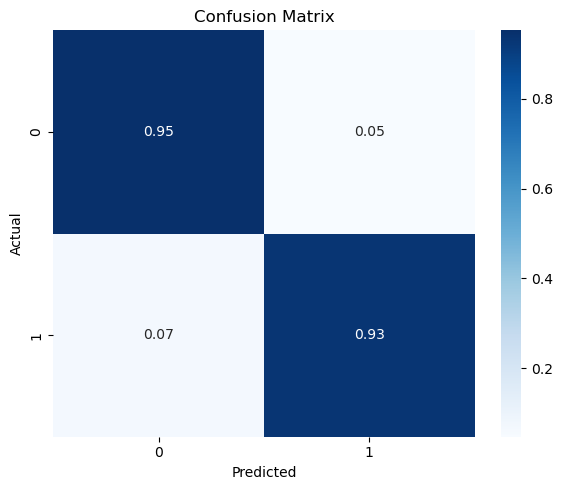

In [29]:
plot_confusion_matrix(test_labels,rounded_predictions,
                      labels=[0,1],
                      normalize=True)

In [33]:
dist_plot=ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(test_labels,rounded_predictions)
                          ,display_labels=[0,1]
                          )
dist_plot.plot()

Save and load the Model


In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,928 (7.54 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,286 (5.03 KB)

In [35]:
# first check whether the model already exists
import os
if os.path.exists('model.h5'):
    print("model already exists,load it")
    model=keras.models.load_model('model.h5')
else:
    print("model does not exist,creating a new one and saving it ")
    model.save('model.h5')

model does not exist,creating a new one and saving it 


In [37]:
from tensorflow.keras.models import load_model
# load the model
new_model=load_model('model.h5')

In [38]:
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644 (2.52 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [39]:
new_model.get_weights()

[array([[-0.44599873,  0.6735947 , -0.4646086 ,  0.5462651 ,  0.25096428,
          0.5474164 , -0.00541824, -0.32898945, -0.26272604,  0.5103218 ,
          0.6899802 ,  0.333828  , -0.11854735,  0.4361712 , -0.12233344,
          0.54137284]], dtype=float32),
 array([ 0.        , -0.3427666 ,  0.        , -0.07950641,  0.20921662,
        -0.2804618 ,  0.        ,  0.        ,  0.        , -0.27230376,
        -0.3658095 , -0.18175022,  0.        , -0.24188407,  0.        ,
        -0.08346774], dtype=float32),
 array([[-2.61426777e-01, -1.75407931e-01, -5.14840484e-02,
         -2.36563593e-01, -1.44877940e-01, -2.18210220e-02,
         -1.06075436e-01,  1.15808904e-01, -3.16291362e-01,
          1.41960949e-01, -2.51804829e-01,  8.36366117e-02,
          3.08567613e-01, -2.20697328e-01, -1.82550475e-01,
         -3.20412487e-01, -2.70883769e-01, -1.39779180e-01,
         -9.43631530e-02,  1.57354921e-01,  2.19775230e-01,
          2.49380857e-01, -2.33993903e-01,  1.93312019e-01,
 

In [40]:
new_model.optimizer

2.to json 

if you want save only architecture of the model not weights and training configurations

In [41]:
json_string=model.to_json()
print(json_string)

{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 1], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"name": "dense", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "units": 16, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initializers", "class_name": "Zeros", "config": {}, "registered_name": null}, "kernel_regularizer": null, "bias_regularizer": null, "kern

In [42]:
from tensorflow.keras.models import model_from_json
# load the model from JSON
model_architecture=model_from_json(json_string)

In [43]:
model_architecture.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,928 (7.54 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,286 (5.03 KB)